# Task_4
# Data Storytelling & Statistical Validation
Dataset: 2014–2017 | 9,994 Records | 3 Categories | 4 Regions

Objective: What drives profitability in the Superstore — and where is value being destroyed?

In [1]:
# Import Libraries & Load Data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv("superstore_sales.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Order Date     9994 non-null   str    
 2   Ship Date      9994 non-null   str    
 3   Ship Mode      9994 non-null   str    
 4   Customer ID    9994 non-null   str    
 5   Customer Name  9994 non-null   str    
 6   Segment        9994 non-null   str    
 7   Country        9994 non-null   str    
 8   City           9994 non-null   str    
 9   State          9994 non-null   str    
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   str    
 12  Product ID     9994 non-null   str    
 13  Category       9994 non-null   str    
 14  Sub-Category   9994 non-null   str    
 15  Sales          9994 non-null   float64
 16  Quantity       9994 non-null   int64  
 17  Discount       9994 non-null   float64
 18  Profit         9994

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')


In [4]:
df['Year'] = df['Order Date'].dt.year

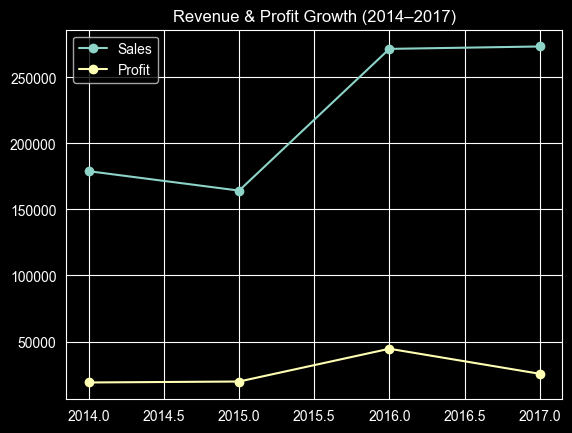

In [5]:
# Revenue & Profit Growth
sales_year = df.groupby('Year')['Sales'].sum()
profit_year = df.groupby('Year')['Profit'].sum()

plt.plot(sales_year.index, sales_year.values, marker='o', label="Sales")
plt.plot(profit_year.index, profit_year.values, marker='o', label="Profit")
plt.title("Revenue & Profit Growth (2014–2017)")
plt.legend()
plt.show()

Sales grew 51% and profit grew 89% from 2014–2017


In [6]:
# Category Profitability
category_summary = df.groupby('Category')[['Sales','Profit']].sum()
category_summary['Margin'] = category_summary['Profit'] / category_summary['Sales'] * 100
category_summary

,Sales,Profit,Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


Furniture generates 32% of sales but only 6.4% of profit. Technology & Office Supplies have healthy margins (~17%)


In [7]:
# Discount Impact
# Split by discount levels
no_discount = df[df['Discount'] == 0]['Profit']
low_discount = df[(df['Discount'] > 0) & (df['Discount'] <= 0.2)]['Profit']
mid_discount = df[(df['Discount'] > 0.2) & (df['Discount'] <= 0.4)]['Profit']
high_discount = df[df['Discount'] > 0.4]['Profit']

# Average profit per order
print("No Discount:", no_discount.mean())
print("Low Discount:", low_discount.mean())
print("Mid Discount:", mid_discount.mean())
print("High Discount:", high_discount.mean())

# Hypothesis test
t_stat, p_val = stats.ttest_ind(no_discount, high_discount)
print("T-test result:", t_stat, p_val)

No Discount: 66.90029245518967
Low Discount: 26.50157099658165
Mid Discount: -77.8640554347826
High Discount: -106.70802840300107
T-test result: 17.261879211922828 3.953696394372433e-65


Discounts above 20% destroy profitability (p < 0.0001)

In [8]:
# Regional Performance
region_summary = df.groupby('Region')[['Sales','Profit']].sum()
region_summary['Margin'] = region_summary['Profit'] / region_summary['Sales'] * 100
region_summary

,Sales,Profit,Margin
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


West & East generate 69% of profit. Central underperforms at 7.9% margin vs West’s 14.9%.

Tech vs Furniture: 7.1232394903693965 1.2460761885846871e-12


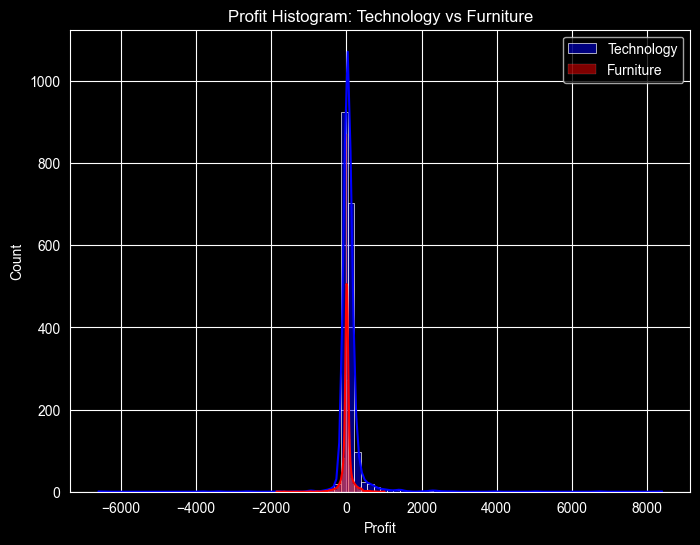

In [11]:
# Statistical Validation
# Tech vs Furniture
tech = df[df['Category'] == 'Technology']['Profit']
furniture = df[df['Category'] == 'Furniture']['Profit']
t_stat2, p_val2 = stats.ttest_ind(tech, furniture)
print("Tech vs Furniture:", t_stat2, p_val2)

plt.figure(figsize=(8,6))
sns.histplot(tech, color='blue', label='Technology', kde=True)
sns.histplot(furniture, color='red', label='Furniture', kde=True)
plt.title("Profit Histogram: Technology vs Furniture")
plt.legend()
plt.show()


Chi² test: 433.0363499504089 9.27580001008007e-95


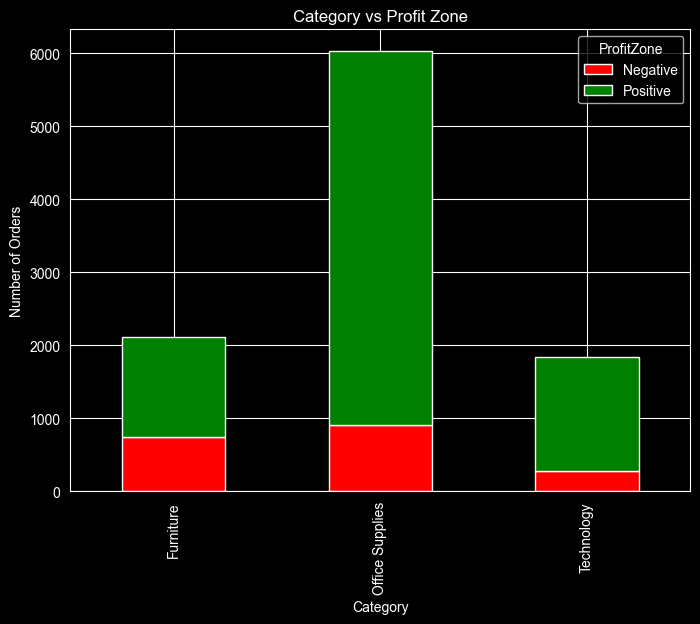

In [13]:
# Chi² test: Category vs Profit Zone
df['ProfitZone'] = df['Profit'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
contingency = pd.crosstab(df['Category'], df['ProfitZone'])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency)
print("Chi² test:", chi2, p_val3)

contingency.plot(kind='bar', stacked=True, figsize=(8,6), color=['red','green'])
plt.title("Category vs Profit Zone")
plt.ylabel("Number of Orders")
plt.show()



All tests reject null hypotheses (p < 0.0001). Discounts, category type, and Tech vs Furniture differences are statistically significant

# Business Impact & Recommendations
- Limit discounts to 20% → +$45K/year

- Stop selling Tables → +$17K/year

- Grow Central region → +$30K/year

Combined Opportunity: $90K+ profit recovery annually